# Bogus Basin Snow Depth

In [558]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
from data_registry import datasets
from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.interpolate import interp1d
from utils import mainutil
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines

import warnings
warnings.filterwarnings("ignore")
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

In [559]:
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)


## Plot and Exploratory Analysis

*Read data*

In [560]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])


snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

# snow_data_monthly = snow_data.resample("ME").mean()

snow_daily = mainutil.to_ts(snow_data['Depth'], snow_data.index)
# snow_monthly = mainutil.to_ts(snow_data_monthly['Depth'], snow_data_monthly.index)

# print(snow_monthly.head())
# print(snow_daily.head())



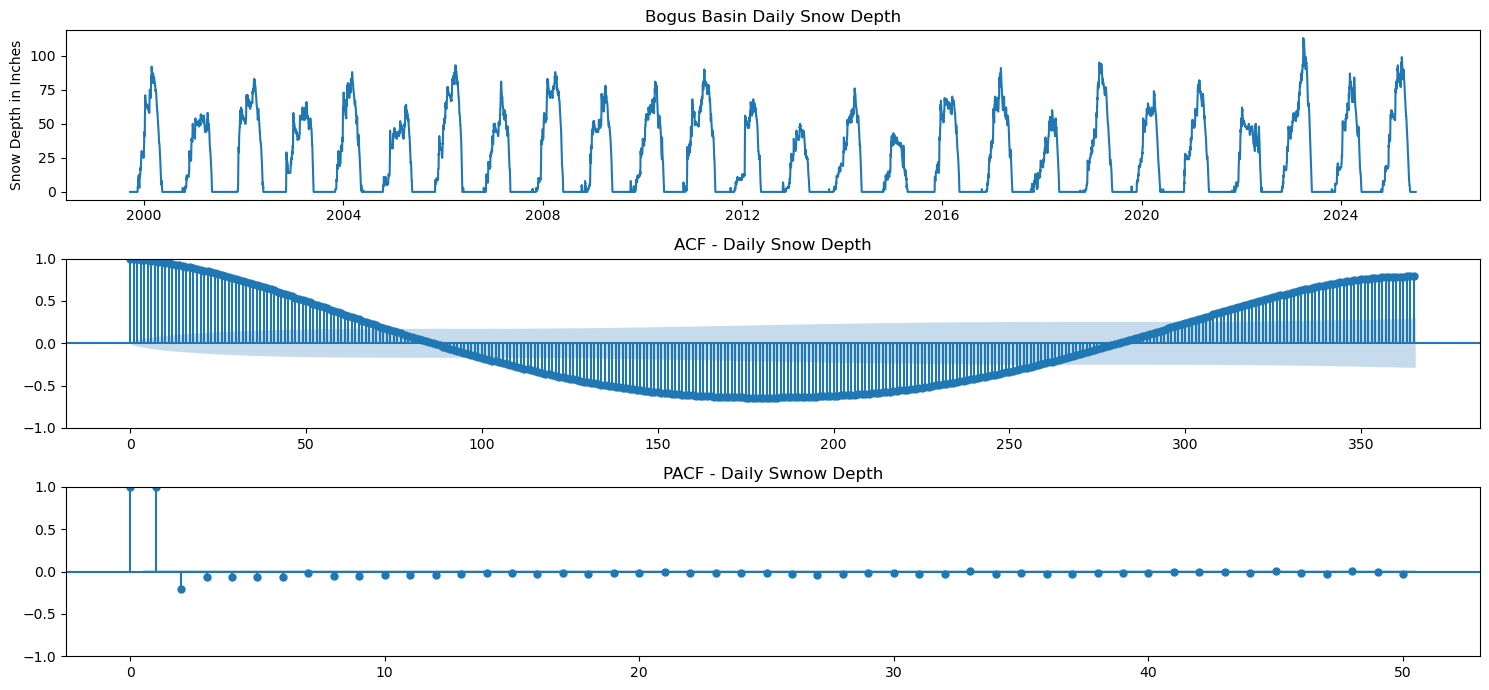

In [561]:
fig, axs = plt.subplots(3,1 ,figsize=(15,7))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")
plot_acf(snow_daily['ts'], lags = 365, ax = axs[1], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[2], title = "PACF - Daily Swnow Depth");

# axs[1].plot(snow_monthly['ts'], marker = '.', markersize = 5  )
# axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
# axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

In [562]:
# fig, axs = plt.subplots(2,2, figsize = (15,10))


# plot_acf(snow_monthly['ts'], lags = 24, ax = axs[1,0], title  = "ACF - Average Monthly Snow Depth");
# plot_pacf(snow_monthly['ts'], lags = 24, ax = axs[1,1], title = 'PACF - Average Monthly Snow Depth');

## Modeling



Splitting data into training and testing data sets, with testing set for the last year's worth of data. Adding in categorical viariables at month, week, and day levels for seasonal analysis 

In [563]:
cutoff_date = '06/01/2024'

sd= snow_daily.copy()
sd['month'] = sd.index.month
sd['week'] = sd.index.isocalendar().week.astype('int')
sd['day'] = sd.index.dayofyear

sd_train = sd[sd.index<cutoff_date]
sd_test = sd[sd.index>=cutoff_date]

# smnth = snow_monthly.copy()
# smnth['month'] = smnth.index.month

# sm_train = smnth[smnth.index<cutoff_date]
# sm_test = smnth[smnth.index>=cutoff_date]

print(sd_train.tail())
print(sd_test.head())
# print(sm_train.tail())
# print(sm_test.head())




            ts       pts  month  week  day
Date                                      
2024-05-27   4  0.957598      5    22  148
2024-05-28   2  0.957705      5    22  149
2024-05-29   1  0.957811      5    22  150
2024-05-30   0  0.957917      5    22  151
2024-05-31   0  0.958023      5    22  152
            ts       pts  month  week  day
Date                                      
2024-06-01   0  0.958130      6    22  153
2024-06-02   0  0.958236      6    22  154
2024-06-03   0  0.958342      6    23  155
2024-06-04   0  0.958448      6    23  156
2024-06-05   0  0.958555      6    23  157


### Trend Estimation Using Moving Average and Local Polynomial

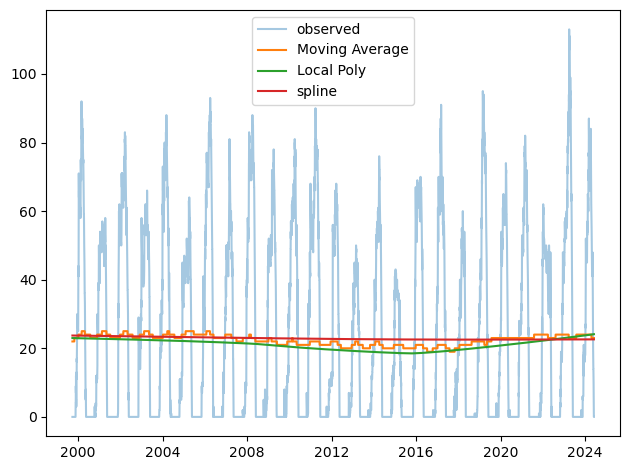

In [564]:
#Moving Average Trend
mavModel = uniform_filter1d(sd_train['ts'], size=len(sd_train['ts'])//2)
mavModel
mav_data = pd.Series(mavModel, index=sd_train.index)
sd_train['mav2'] = sd_train['ts'].rolling(window =365, center = True, min_periods=1).mean()

#lowess trend
localPolyModel = sm.nonparametric.lowess(endog=sd_train['ts'], exog=sd_train['pts'], is_sorted=True, frac=0.7)

## extrapolate local polynomial and Moving Average onto test data
f = interp1d(localPolyModel[:,0], localPolyModel[:,1], bounds_error=False, fill_value="extrapolate")
sd_test['LocalPoly_Trend'] = f(sd_test['pts'])
sd_test['MovingAvg_Trend'] = mav_data[-1]
#sd_test['MovingAvg_Trend'] = uniform_filter1d(sd_test['ts'], size=len(sd_test['ts'])//2)

gamModel = GLMGam.from_formula(
    formula='ts ~ 1', data=sd_train, alpha=100,
    family=sm.families.Gaussian(),
    smoother=BSplines(sd_train['pts'], df=500, degree=3)).fit()



localPolyData = pd.Series(localPolyModel[:,1], index=sd_train.index)
sd_train['MovingAvg_Trend'] = mav_data
sd_train['LocalPoly_Trend'] = localPolyData
sd_train['spline'] = gamModel.fittedvalues
plt.plot(sd_train['ts'], alpha =.4)
plt.plot(sd_train['MovingAvg_Trend'])
plt.plot(sd_train['LocalPoly_Trend'])

plt.plot(sd_train['spline'])
# plt.plot(sd_test['LocalPoly_Trend'])
# plt.plot(sd_test['MovingAvg_Trend'])

plt.legend(['observed', 'Moving Average', 'Local Poly', 'spline'])
plt.tight_layout()

### Seaonality Estimation

In [565]:
def generate_fourier_terms(time, period, K):

    fourier_terms = {}
    for k in range(1, K + 1):
        fourier_terms[f'sin_{k}'] = np.sin(2 * np.pi * k * time / period)
        fourier_terms[f'cos_{k}'] = np.cos(2 * np.pi * k * time / period)
    return pd.DataFrame(fourier_terms)


f_train = generate_fourier_terms(sd_train.index.dayofyear, 365, 3)
f_train =f_train.set_index(sd_train.index)
f_train


,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614,0.920971,0.389630
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118,0.939856,0.341571
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469,0.956235,0.292600
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452
...,...,...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720,0.977848,0.209315
2024-05-28,0.545240,-0.838280,-0.914128,0.405426,0.987349,0.158559
2024-05-29,0.530730,-0.847541,-0.899631,0.436651,0.994218,0.107381


In [566]:
sd_train =sd_train.join(f_train)


In [567]:


#sd_train['mavtrend'] = mav_data
sd_train['ts_sqrt'] = np.sqrt(sd_train['ts'])
#sd_train['ts_log'] = np.log(sd_train['ts']+1)
# sd_train['cos1'] = np.cos(2 * np.pi * (sd_train.index.dayofyear - 1) / 365)
# sd_train['sin1'] = np.sin(2 * np.pi * (sd_train.index.dayofyear - 1) / 365)
# sd_train['cos2'] = np.cos(2 * np.pi * (sd_train.index.month - 1) / 365)
# sd_train['sin2'] = np.sin(2 * np.pi * (sd_train.index.month - 1) /365)


# seasonalmodel_no_trend = smf.ols(formula = 'ts_sqrt~ sin1 + cos1', data = sd_train).fit()
# seasonalmodel_MA_trend = smf.ols(formula = 'ts_sqrt~ sin1 + cos1+ + cos2 + sin2 +MovingAvg_Trend', data = sd_train).fit()
#seasonalmodel_LocalPoly_trend_myf = smf.ols(formula = 'ts_sqrt~ sin1 + cos1+ +cos2 +sin2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic2 = smf.ols(formula = 'ts_sqrt~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic3 = smf.ols(formula = 'ts_sqrt~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
seasonal_model_WeeklyAnova_w_Poly = smf.ols(formula = 'ts_sqrt~C(week)+LocalPoly_Trend', data = sd_train).fit()
# seasonal_model_DailyAnova_w_Poly = smf.ols(formula = 'ts_sqrt~C(day)+MovingAvg_Trend', data = sd_train).fit()


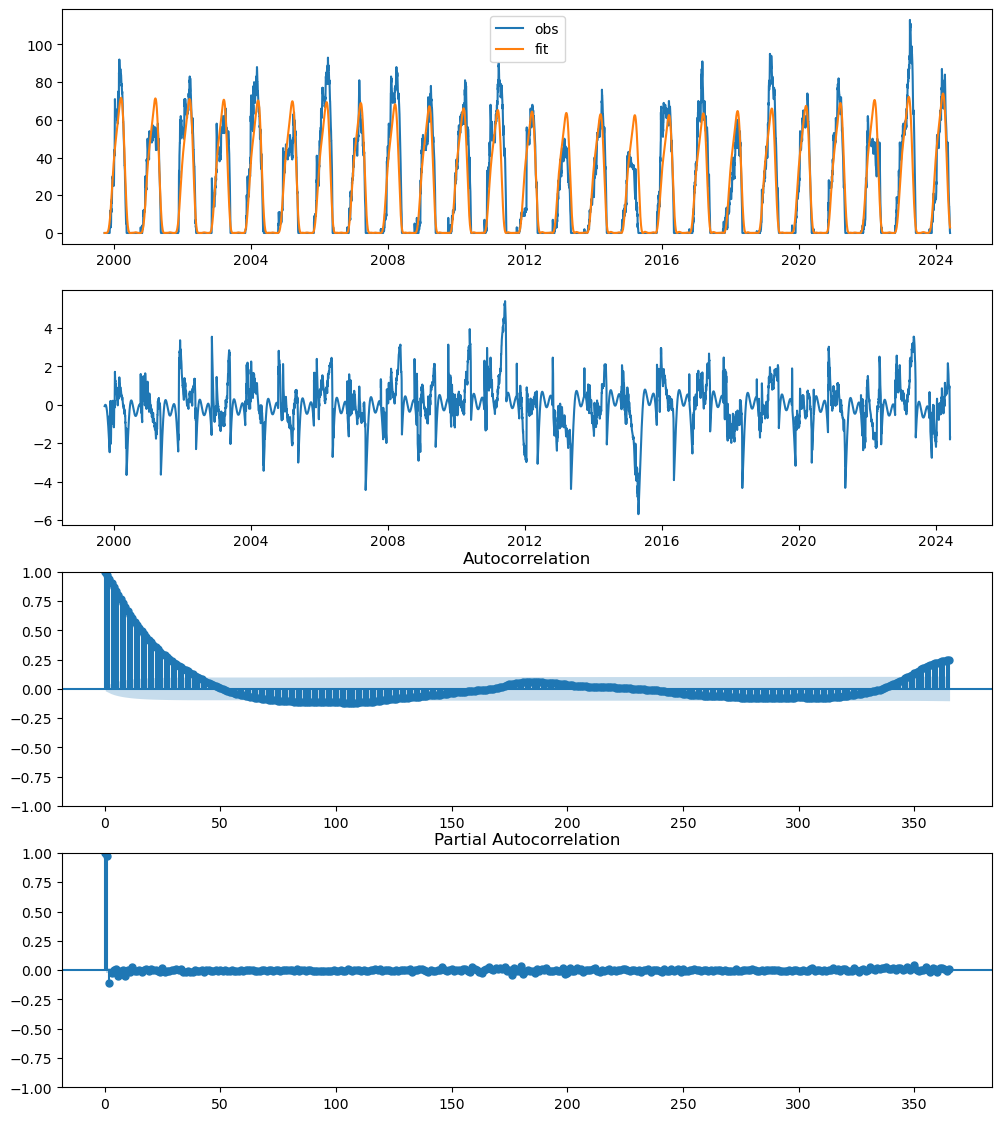

In [568]:
fig, axs = plt.subplots(4,1, figsize =(12,14) )
axs[0].plot(sd_train['ts'])
axs[0].plot(seasonalmodel_LocalPoly_trend_Harmonic3.fittedvalues**2)
#axs[0].plot(seasonalmodel_LocalPoly_trend_Harmonic2.fittedvalues**2)

axs[1].plot(seasonalmodel_LocalPoly_trend_Harmonic3.resid)
axs[0].legend(['obs', 'fit',])

plot_acf(seasonalmodel_LocalPoly_trend_Harmonic3.resid**2, lags = 365, ax = axs[2]);
plot_pacf(seasonalmodel_LocalPoly_trend_Harmonic3.resid**2, lags = 365, ax = axs[3]);
#plt.plot(seasonalmodel.params)

Prepping test data for forecasting

In [569]:
f_test = generate_fourier_terms(sd_test.index.dayofyear, 365, 3)
f_test = f_test.set_index(sd_test.index)
sd_test = sd_test.join(f_test)

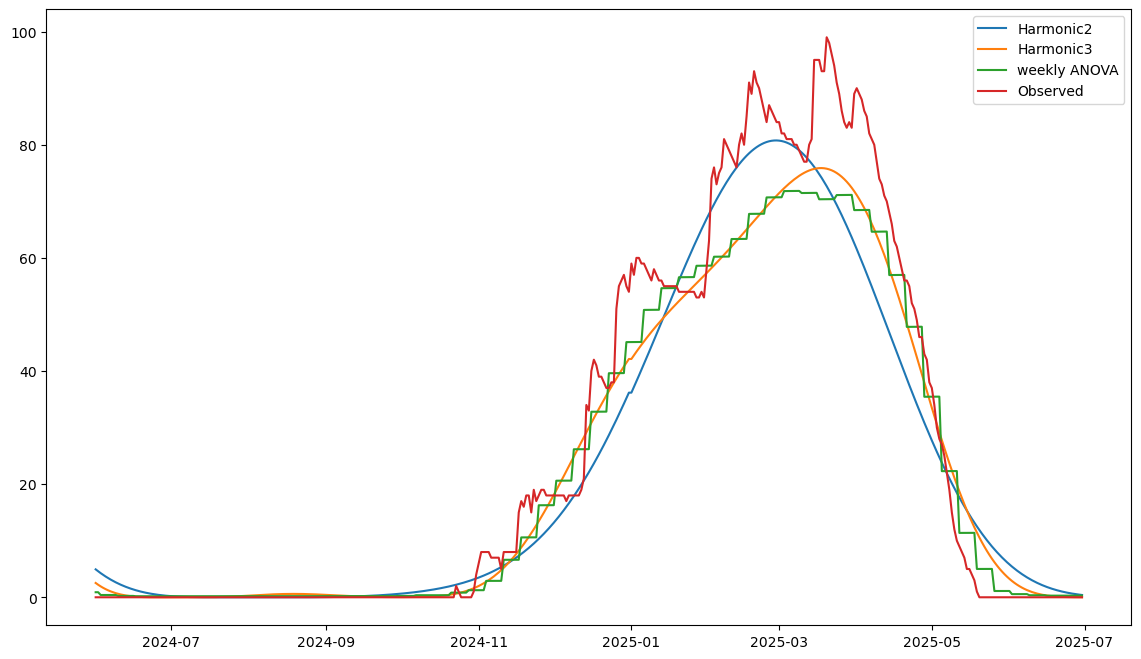

In [570]:

sd_test['ts_sqrt'] = np.sqrt(sd_test['ts'])
sd_test['ts_log'] = np.log(sd_test['ts']+1)


plt.figure( figsize = (14,8))
#plt.plot(seasonalmodel_LocalPoly_trend_myf.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test)**2)
#plt.plot(seasonalmodel_no_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_LocalPoly_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_MA_trend.predict(exog=sd_test)**2)
plt.plot(seasonal_model_WeeklyAnova_w_Poly.predict(exog=sd_test)**2)
# plt.plot(seasonal_model_DailyAnova_w_Poly.predict(exog=sd_test)**2)
plt.plot(sd_test['ts'])
plt.legend(['Harmonic2', 'Harmonic3', "weekly ANOVA", 'Observed'])

In [571]:
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test)**2, 'local poly harmonic 2' )
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test)**2, 'local poly harmonic 3' )
evaluate_performance(sd_test['ts'],seasonal_model_WeeklyAnova_w_Poly.predict(exog = sd_test)**2, 'weekly anova' )

=== local poly harmonic 2 Performance ===
MSPE: 87.7649
MAE:  5.8581
MAPE: 713371.2818
PM:   0.0801
----------------------------------------
=== local poly harmonic 3 Performance ===
MSPE: 63.0688
MAE:  4.9660
MAPE: 386794.2247
PM:   0.0576
----------------------------------------
=== weekly anova Performance ===
MSPE: 64.9154
MAE:  4.7719
MAPE: 224109.9961
PM:   0.0593
----------------------------------------


In [572]:
maxp=4
maxd=2
maxq=4

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = f_train,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(0, 1, 4) 36307.089148612715


In [573]:
arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = f_train,
                order=selected_orders ).fit()
print(arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                     ts   No. Observations:                 9016
Model:               SARIMAX(0, 1, 4)   Log Likelihood              -18093.921
Date:                Thu, 23 Apr 2026   AIC                          36209.842
Time:                        21:06:38   BIC                          36288.015
Sample:                             0   HQIC                         36236.440
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         27.9409      3.704      7.544      0.000      20.682      35.200
cos_1         17.8729      3.599      4.965      0.000      10.818      24.928
sin_2          8.4882      2.535      3.349      0.0

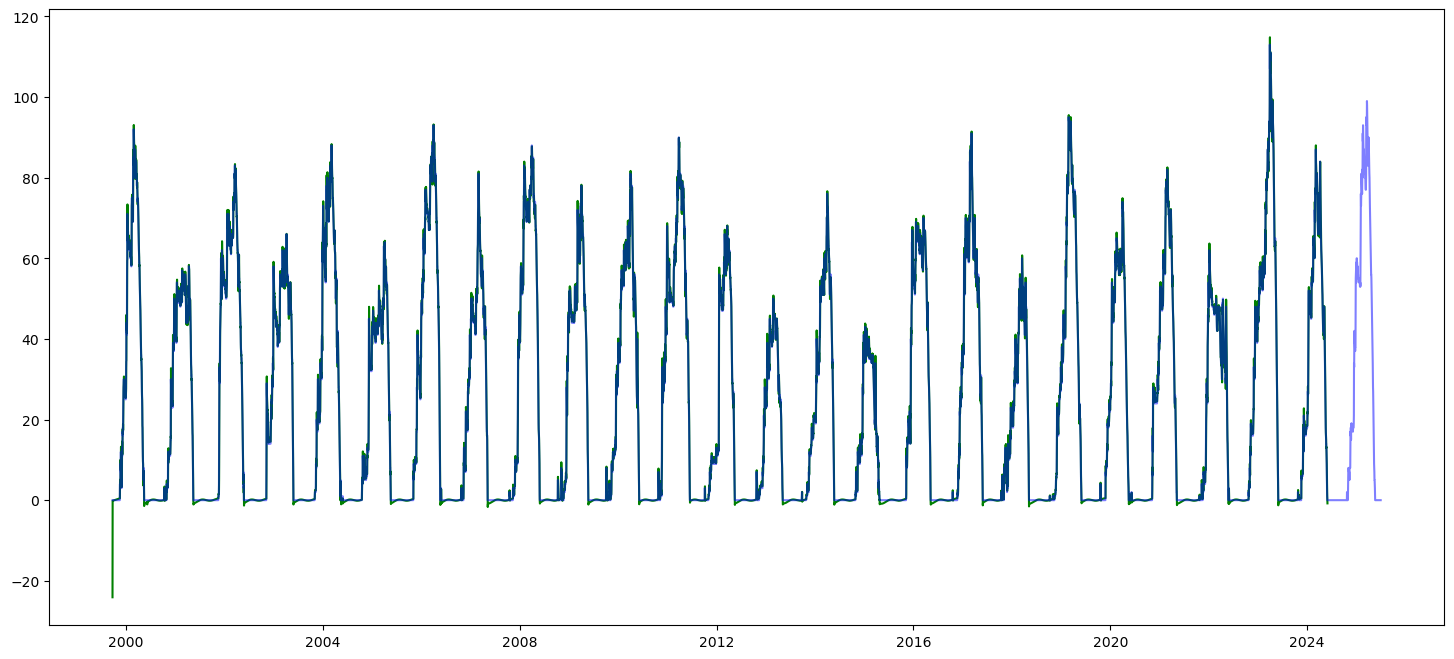

In [574]:
plt.figure(figsize= (18,8))
plt.plot(arima_fourier_model.fittedvalues, color = 'green')
plt.plot(sd['ts'], alpha=.5 ,color = 'blue')
forecast= arima_fourier_model.forecast(steps = 395, exog = f_test)


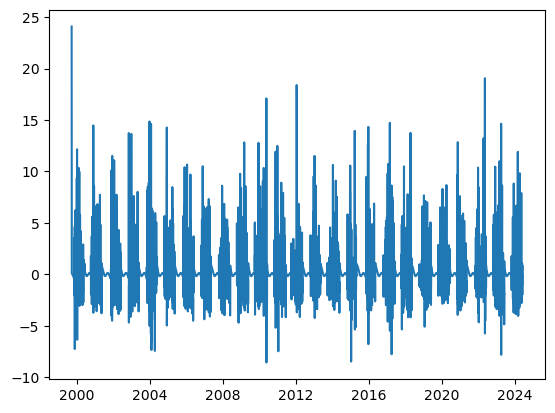

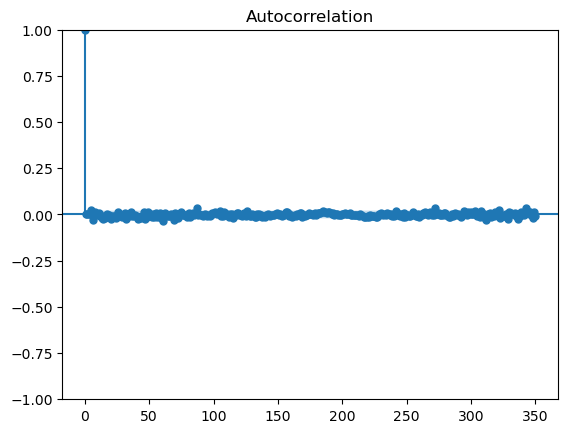

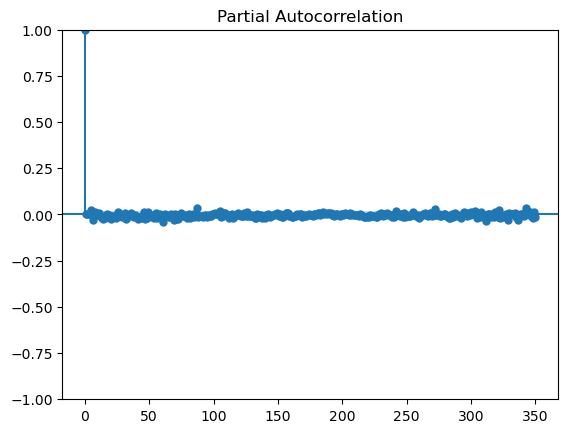

In [575]:
plt.plot(arima_fourier_model.resid)
plot_acf(arima_fourier_model.resid, lags = 350);
plot_pacf(arima_fourier_model.resid, lags = 350);

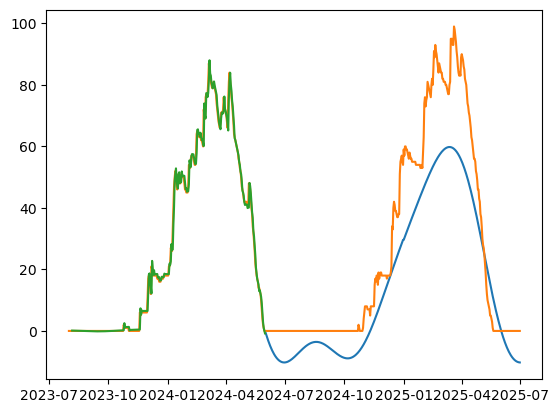

In [576]:
plt.plot(sd_test.index, forecast )
plt.plot(sd['ts'][-700:])
plt.plot(arima_fourier_model.fittedvalues[-300:])


In [577]:
evaluate_performance(sd_test['ts'], forecast, 'Arima' )

=== Arima Performance ===
MSPE: 242.7873
MAE:  12.4450
MAPE: nan
PM:   0.0000
----------------------------------------


In [578]:
    
test = pd.concat([sd_train.tail(), sd_test.head()])
print(test)

            ts       pts  month  week  day       mav2  MovingAvg_Trend  \
Date                                                                     
2024-05-27   4  0.957598      5    22  148  45.518717               23   
2024-05-28   2  0.957705      5    22  149  45.731183               23   
2024-05-29   1  0.957811      5    22  150  45.945946               23   
2024-05-30   0  0.957917      5    22  151  46.163043               23   
2024-05-31   0  0.958023      5    22  152  46.382514               23   
2024-06-01   0  0.958130      6    22  153        NaN               23   
2024-06-02   0  0.958236      6    22  154        NaN               23   
2024-06-03   0  0.958342      6    23  155        NaN               23   
2024-06-04   0  0.958448      6    23  156        NaN               23   
2024-06-05   0  0.958555      6    23  157        NaN               23   

            LocalPoly_Trend     spline     sin_1     cos_1     sin_2  \
Date                                   

In [579]:
sd_train_roll = sd_train.copy()
sd_train_roll[7:14]

,ts,pts,month,week,day,mav2,MovingAvg_Trend,LocalPoly_Trend,spline,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,ts_sqrt
Date,,,,,,,,,,,,,,,,
1999-09-30,0,0.000744,9,39,273,37.021053,22,22.982568,23.727642,-0.999917,-0.012910,0.025818,-0.999667,0.999250,0.038722,0.0
1999-10-01,0,0.000850,10,39,274,37.209424,22,22.982182,23.727402,-0.999991,0.004304,-0.008607,-0.999963,0.999917,-0.012910,0.0
1999-10-02,0,0.000956,10,39,275,37.385417,22,22.981797,23.727162,-0.999769,0.021516,-0.043022,-0.999074,0.997917,-0.064508,0.0
1999-10-03,0,0.001063,10,39,276,37.549223,22,22.981412,23.726922,-0.999250,0.038722,-0.077386,-0.997001,0.993257,-0.115935,0.0
1999-10-04,0,0.001169,10,40,277,37.701031,22,22.981027,23.726681,-0.998435,0.055917,-0.111659,-0.993747,0.985948,-0.167052,0.0
1999-10-05,0,0.001275,10,40,278,37.835897,22,22.980641,23.726441,-0.997325,0.073095,-0.145799,-0.989314,0.976011,-0.217723,0.0
1999-10-06,0,0.001382,10,40,279,37.964286,22,22.980256,23.726201,-0.995919,0.090252,-0.179767,-0.983709,0.963471,-0.267814,0.0


In [584]:
forecast_period = 7
number_of_runs = len(sd_test)//forecast_period
results = []
for r in range(1,number_of_runs):
    if r == 1:
        train_rolling = sd_train.copy()
        test_rolling = sd_test.copy()[:forecast_period]
    else: 
        train_rolling = pd.concat([train_rolling, test_rolling])
        test_rolling = sd_test.copy()[forecast_period*(r-1):forecast_period*r]
    f_train = train_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']]
    f_test = test_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']]
    
    if len(test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(test_rolling)
    model = sm.tsa.statespace.SARIMAX(
                train_rolling['ts'], 
                exog = f_train,
                order=selected_orders ).fit()
    forecast = model.forecast(steps = forecast_period, exog = f_test)
    forecast = forecast.set_axis(test_rolling.index)
     
    results.append(forecast)
full_forecast = pd.concat(results)




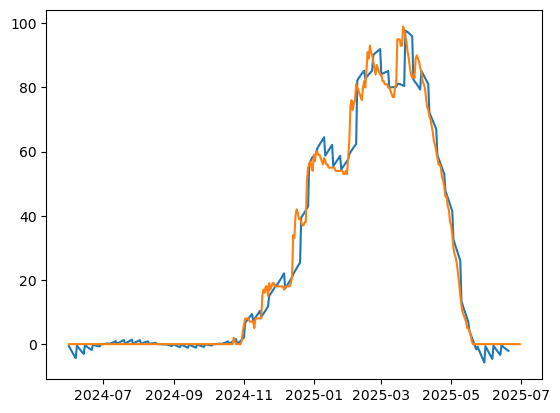

In [585]:
plt.plot(full_forecast)
plt.plot(sd_test['ts'])


In [586]:
evaluate_performance(sd_test['ts'][:385], full_forecast, "arima 7 day rolling")

=== arima 7 day rolling Performance ===
MSPE: 21.6790
MAE:  2.8423
MAPE: 423315.9707
PM:   0.0196
----------------------------------------


## Facebook Prophet

In [589]:
prof_train = pd.DataFrame( sd_train.index, sd_train.copy()['ts']).reset_index()

prof_train.rename(columns={'ts':'y', 'Date':'ds'}, inplace=True)
prof_train.head()

prof_test = pd.DataFrame( sd_test.index, sd_test.copy()['ts']).reset_index()

prof_test.rename(columns={'ts':'y', 'Date':'ds'}, inplace=True)
prof_test.head()

,y,ds
0,0,2024-06-01
1,0,2024-06-02
2,0,2024-06-03
3,0,2024-06-04
4,0,2024-06-05


21:22:14 - cmdstanpy - INFO - Chain [1] start processing
21:22:15 - cmdstanpy - INFO - Chain [1] done processing


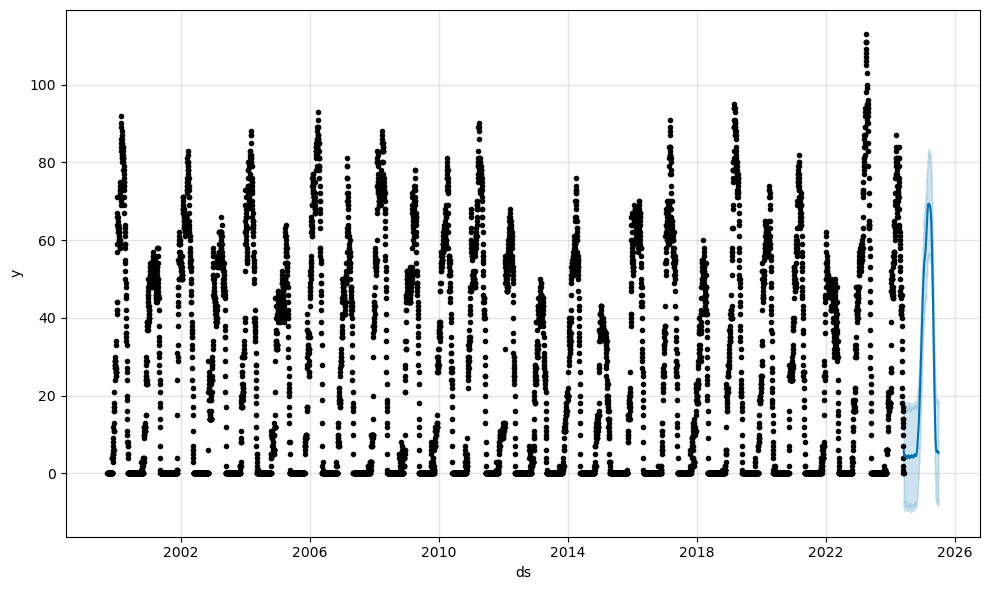

In [590]:
m = Prophet()
m.fit(prof_train)
prof_forecast = m.predict(prof_test)
plot = m.plot(prof_forecast)
plot.show()

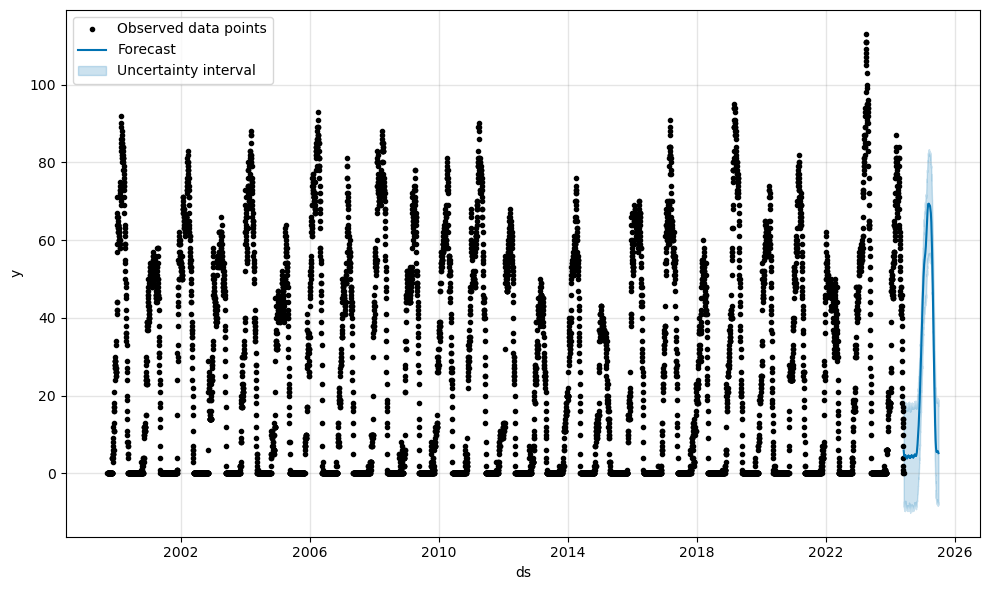

In [591]:
plot=m.plot(prof_forecast, include_legend=True, )
plot.show()

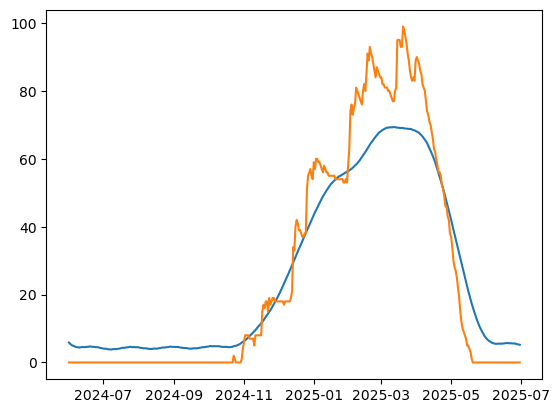

In [597]:
plt.plot(sd_test.index, prof_forecast['yhat'])
plt.plot(sd_test['ts'])

In [595]:
evaluate_performance(sd_test['ts'], prof_forecast['yhat'], 'profet')

=== profet Performance ===
MSPE: 97.5684
MAE:  7.5798
MAPE: nan
PM:   0.0000
----------------------------------------
